# **Curso de Data Science · UTN FRBA — Centro de e-Learning**
## 1era entrega - actividad práctica del módulo 1


### 👤 **Datos del alumno**

| Campo | Dato |
|---|---|
| Nombre y apellido | Noelia Leder |
| Comisión |  |
| Fecha de entrega | 29/07/2026 |


---
# 1. Selección y alcance del dataset

## 1.1 Descripción del dataset elegido
- **Nombre / fuente:** dataset_cafeteria_moderna, fuente Claude IA
- **Link de descarga:** https://drive.google.com/file/d/1ArzdEqAgGdhZ_8Aea_Vv066CXGoJ04R5/view?usp=drivesdk
- **Formato:** `.csv`
- **Diccionario de data set con unidades** (¿qué representa cada columna?)
Id de la transacción, fecha, hora, sucursal, dni del cliente, edad del cliente categoria del producto, producto, cantidad comprada, precio unitario, costo unitario, propina, metodo de pago, canal, calificacion del servicio-
- **Cantidad de filas y columnas:** 1034 filas y 15 columnas


## 1.2 Preguntas de investigación
**Pregunta 1:** ¿Cómo evolucionó la rentabilidad mensual de la cafetería durante el año?

**Pregunta 2:** ¿La propina está más influenciada por la satisfacción del cliente (calificación) o por el monto consumido?

**Pregunta 3:** ¿Los precios aumentaron al mismo ritmo que los costos?

## 1.3 Validación de viabilidad

| Pregunta | Columnas necesarias | ¿Están en el dataset? | ¿Viable? (Sí / Reformular) |
|---|---|---|---|
| P1 | fecha, precio unitario, costo unitario y cantidad | sí | sí |
| P2 | propina, calificación, precio unitario, cantidad  | sí | sí |
| P3 | fecha, precio unitario, costo unitario | sí | sí |


# 2. Carga del dataset


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RUTA_ARCHIVO = "/content/dataset_cafeteria_moderna.csv"


In [2]:
data_original = pd.read_csv(RUTA_ARCHIVO, sep=",", encoding="utf-8")
df = data_original.copy()

# 3. Exploración inicial


In [3]:
df.head() #visualización de la tabla (carga correcta)

,id_transaccion,fecha,hora,sucursal,dni_cliente,edad_cliente,categoria_producto,producto,cantidad,precio_unitario,costo_unitario,propina,metodo_pago,canal,calificacion
0,T1220,2024-06-04,11:17,Caballito,43360019.0,36.0,Bebidas,Agua saborizada,1,4320.0,1060.0,650.0,Efectivo,Delivery,4.0
1,T1323,2024-10-19,09:06,Palermo,35447447.0,35.0,Café,Cold brew,2,3900.0,780.0,2870.0,Tarjeta de crédito,Salón,4.0
2,T1162,2024-06-17,14:21,Caballito,41845171.0,17.0,Panes,Pan integral,3,2830.0,890.0,0.0,Transferencia,Salón,4.0
3,T1442,2024-12-17,16:15,Caballito,28002175.0,33.0,Sandwiches,Bagel de salmón ahumado,3,6100.0,2290.0,2220.0,Efectivo,Salón,2.0
4,T1394,2024-08-20,07:06,Palermo,38030831.0,24.0,Tortas,Cheesecake de frutos rojos,1,5160.0,1750.0,780.0,Tarjeta de débito,Salón,2.0


In [4]:
df.shape #la tabla tiene 1034 filas y 15 columnas

(1034, 15)

In [5]:
df.info() #visualización de la cantidad de NaN y formato de cada columna
#se observa que sucursal, dni_cliente, edad_cliente, costo_unitario, propina, metodo_pago y calificación tienen faltante de datos
#se observa que fecha, hora, edad_cliente, precio_unitario, calificación tienen formatos inadecuados, es necesario corregirlos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1034 entries, 0 to 1033
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_transaccion      1034 non-null   object 
 1   fecha               1034 non-null   object 
 2   hora                1034 non-null   object 
 3   sucursal            1024 non-null   object 
 4   dni_cliente         1003 non-null   object 
 5   edad_cliente        1019 non-null   float64
 6   categoria_producto  1034 non-null   object 
 7   producto            1034 non-null   object 
 8   cantidad            1034 non-null   int64  
 9   precio_unitario     1034 non-null   object 
 10  costo_unitario      1013 non-null   float64
 11  propina             1008 non-null   float64
 12  metodo_pago         1019 non-null   object 
 13  canal               1034 non-null   object 
 14  calificacion        877 non-null    float64
dtypes: float64(4), int64(1), object(10)
memory usage: 121.3

# 4. Diagnóstico


In [6]:
df.isnull().sum() #sucursal, dni_cliente, edad_cliente, costo_unitario, propina, metodo_pago y calificación tienen valores nulos
nulos = df.isnull().sum()
porcentaje_nulos = ((df.isnull().mean())*100).round(2)

resumen_nulos = pd.DataFrame({
    'nulos': nulos,
    'Porcentaje de nulos': porcentaje_nulos
})

nulos_mayor_cero = resumen_nulos[resumen_nulos['nulos'] > 0] #agrego una máscala booleana
nulos_mayor_cero

,nulos,Porcentaje de nulos
sucursal,10,0.97
dni_cliente,31,3.00
edad_cliente,15,1.45
costo_unitario,21,2.03
propina,26,2.51
metodo_pago,15,1.45
calificacion,157,15.18


In [7]:
df[df.duplicated(keep=False)].sort_values("fecha") #hay 9 duplicados, se ordenan con el fin de comprobar que estén duplicadas, eliminarlas luego

,id_transaccion,fecha,hora,sucursal,dni_cliente,edad_cliente,categoria_producto,producto,cantidad,precio_unitario,costo_unitario,propina,metodo_pago,canal,calificacion
289,T1379,2024-02-04,07:26,Palermo,37624944.0,50.0,Sandwiches,Tostado jamón y queso,1,4610.0,1510.0,0.0,Efectivo,Take away,4.0
784,T1379,2024-02-04,07:26,Palermo,37624944.0,50.0,Sandwiches,Tostado jamón y queso,1,4610.0,1510.0,0.0,Efectivo,Take away,4.0
195,T1240,2024-02-26,20:36,Caballito,25.004.458,32.0,Sandwiches,Tostado jamón y queso,3,6010.0,2130.0,5750.0,Efectivo,Take away,3.0
907,T1240,2024-02-26,20:36,Caballito,25.004.458,32.0,Sandwiches,Tostado jamón y queso,3,6010.0,2130.0,5750.0,Efectivo,Take away,3.0
97,T1090,2024-06-22,10:21,Belgrano,22562866.0,39.0,Sandwiches,Sandwich vegetariano,2,6900.0,2940.0,690.0,Transferencia,Take away,5.0
997,T1090,2024-06-22,10:21,Belgrano,22562866.0,39.0,Sandwiches,Sandwich vegetariano,2,6900.0,2940.0,690.0,Transferencia,Take away,5.0
549,T1354,2024-07-11,17:34,Belgrano,39158964.0,50.0,Sandwiches,Tostado jamón y queso,2,4870.0,2050.0,1290.0,Transferencia,Salón,5.0
871,T1354,2024-07-11,17:34,Belgrano,39158964.0,50.0,Sandwiches,Tostado jamón y queso,2,4870.0,2050.0,1290.0,Transferencia,Salón,5.0
885,T1588,2024-08-05,17:32,Belgrano,36094582.0,38.0,Panes,Pan de nuez y pasas,1,3570.0,910.0,2350.0,Mercado Pago,Salón,NaN
1023,T1588,2024-08-05,17:32,Belgrano,36094582.0,38.0,Panes,Pan de nuez y pasas,1,3570.0,910.0,2350.0,Mercado Pago,Salón,NaN


In [8]:
df.columns.tolist()

['id_transaccion',
 'fecha',
 'hora',
 'sucursal',
 'dni_cliente',
 'edad_cliente',
 'categoria_producto',
 'producto',
 'cantidad',
 'precio_unitario',
 'costo_unitario',
 'propina',
 'metodo_pago',
 'canal',
 'calificacion']

In [9]:
#análisis de los los distintos valores que se encuentran dentro de cada columna
df["id_transaccion"].value_counts(dropna=False)
df["id_transaccion"].unique() #no tiene inconsistencias de texto

df["fecha"].value_counts(dropna=False)
df["fecha"].unique() #tiene inconsistencias de texto (barras y guiones)

df["hora"].value_counts(dropna=False)
df["hora"].unique() #tiene inconsistencias (AM, PM, segundos)

df["sucursal"].value_counts(dropna=False) #ya acá se visualizan inconsistencias en cuanto a las mayúsculas y minúsculas
df["sucursal"].unique()

df["dni_cliente"].value_counts(dropna=False)
df["dni_cliente"].unique() #tiene inconsistencias de texto  (puntos de millones, "sin dato")

df["edad_cliente"].value_counts(dropna=False)
df["edad_cliente"].unique() #tiene valores imposibles

df["producto"].value_counts(dropna=False)
df["producto"].unique() #tiene inconsistencias de texto, conviene pasarlo todo a minuscula, hay dobles espacios

df["precio_unitario"].value_counts(dropna=False)
df["precio_unitario"].unique() #tiene inconsistencias de texto, puntos y $

df["categoria_producto"].value_counts(dropna=False) #ya acá se notan inconsistencias por mayusculas y tildes
df["categoria_producto"].unique()

df["metodo_pago"].value_counts(dropna=False) #ya acá se detectan inconsistencias por mayúsculas y tildes
df["metodo_pago"].unique()

df["cantidad"].value_counts(dropna=False)
df["cantidad"].unique() #no tiene inconsistencias de texto

df["propina"].value_counts(dropna=False)
df["propina"].unique() #tiene valores imposibles (negativos), algunos valores atípicos, nan

df["canal"].value_counts(dropna=False) #ya desde acá se detectan inconsistencias de texto por minúsculas y tildes
df["canal"].unique() #tiene inconsistencias de texto

df["calificacion"].value_counts(dropna=False) #no tiene inconsistencias - la escala va de 1 a 5
df["calificacion"].unique()

df["costo_unitario"].value_counts(dropna=False)
df["costo_unitario"].unique() #no tiene inconsistencias de texto, puntos o $

array([1060.        ,  780.        ,  890.        , 2290.        ,
       1750.        ,  740.        , 1030.        , 1440.        ,
        700.        , 2100.        ,  800.        , 1700.        ,
       1940.        ,  970.        ,  490.        ,  650.        ,
       2720.        ,  630.        ,  770.        ,  610.        ,
                 nan,  950.        ,  510.        ,  660.        ,
       1660.        , 2060.        ,  600.        , 2030.        ,
        520.        , 2380.        ,  500.        ,  730.        ,
        750.        ,  720.        , 1540.        , 1200.        ,
       1010.        , 2210.        , 2870.        ,  840.        ,
        690.        ,  940.        , 1320.        ,  810.        ,
        930.        , 1680.        ,  990.        ,  560.        ,
        540.        , 2130.        , 2500.        , 1040.        ,
       1720.        ,  420.        , 2620.        , 2270.        ,
       1990.        , 1360.        , 2010.        , 1000.     

###Tabla de hallazgos del diagnóstico

| # | Dimensión | Problema detectado | Evidencia (método/salida) | Acción propuesta |
|---|---|---|---|---|
| 1 | Nulos | se detectan NaN en diferentes columnas | value_counts(dropna=False) | se analiza cada situación en particular para tomar una acción (fillna, dropna, no modificarlos) |
| 2 | Formatos | se detectan formatos incorrectos en diversas columnas | info() | modificar los formatos con pd.to_datetime/astype |
| 3 | Inconsistencias | se encontraron, en principio, inconsistencias por mayúsculas/minúsculas | unique() | normalizar los datos con strip(), lower() y replace() |
| 4 | Varianza nula |no se detectaron columnas de varianza nula| - | - |
| 5 | Rangos anómalos | se encontraron valores imposibles y atípicos | unique() | debe ser analizado con describe() y el IQR para determinar su validez |


# 5. Limpieza


In [10]:
#elimino todos los duplicados
df = df.drop_duplicates()
df[df.duplicated(keep=False)] #la corroboración descarta algun tipo de duplicado que no se haya eliminado


,id_transaccion,fecha,hora,sucursal,dni_cliente,edad_cliente,categoria_producto,producto,cantidad,precio_unitario,costo_unitario,propina,metodo_pago,canal,calificacion


In [11]:
#"fecha" tiene inconsistencias en cuanto a guiones/barras y formato de texto
df["fecha"] = df["fecha"].str.replace("/", "-")
df["fecha"] = pd.to_datetime(df["fecha"], format='mixed', dayfirst=True)
df.sort_values("fecha", ascending=True) #Acá lo ordeno para saber que las fechas sean coherentes

,id_transaccion,fecha,hora,sucursal,dni_cliente,edad_cliente,categoria_producto,producto,cantidad,precio_unitario,costo_unitario,propina,metodo_pago,canal,calificacion
164,T1247,2024-01-01,20:05,Villa Urquiza,40772413.0,47.0,Alfajores,Alfajor triple,1,2420.0,720.0,460.0,Tarjeta de crédito,Take away,5.0
644,T1247,2024-01-01,20:05,Villa Urquiza,40772413.0,47.0,Alfajores,Alfajor triple,1,2200.0,600.0,460.0,Tarjeta de crédito,Take away,5.0
561,T1504,2024-01-02,16:30,Palermo,20321404.0,35.0,Alfajores,Alfajor de maicena,1,2670.0,690.0,770.0,Tarjeta de débito,Salón,NaN
77,T1504,2024-01-02,16:30,Palermo,20321404.0,35.0,Tortas,Carrot cake,1,5050.0,2010.0,770.0,Tarjeta de débito,Salón,NaN
994,T1283,2024-01-03,18:47,Palermo,39394030.0,30.0,Bebidas,Smoothie de frutos rojos,1,3700.0,760.0,690.0,Transferencia,Salón,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
335,T1342,2024-12-30,21:12,Caballito,23025927.0,54.0,Tortas,Torta de limón y merengue,2,5130.0,2140.0,2250.0,Tarjeta de crédito,Salón,5.0
771,T1332,2024-12-30,07:02:00,Belgrano,37764231.0,28.0,Sandwiches,Sandwich vegetariano,1,5670.0,2550.0,850.0,Tarjeta de crédito,Salón,4.0
419,T1187,2024-12-30,15:49,Caballito,34212826.0,45.0,Panes,Pan de nuez y pasas,1,2850.0,830.0,NaN,Mercado Pago,Salón,5.0
697,T1102,2024-12-31,17:21,Belgrano,24617076.0,36.0,Sandwiches,Tostado jamón y queso,1,$7.260,3010.0,1040.0,Efectivo,Salón,5.0


In [12]:
#"hora" tiene inconsistencias de texto (AM/PM, segundos, espacios)
df["hora"] = df["hora"].str.replace(" :", ":", regex=False).str.strip() #corrijo el formato

df["hora"] = pd.to_datetime(df["hora"], format='mixed', errors='coerce').dt.time

#reviso cuántas filas no se pudieron interpretar (se convierten en valores nulos)
df["hora"].isnull().sum()

#las elimino (2)
df = df.dropna(subset=["hora"])

In [13]:
df["hora"].sort_values()

,hora
961,07:00:00
941,07:00:00
91,07:02:00
771,07:02:00
327,07:02:00
...,...
471,21:55:00
12,21:56:00
483,21:58:00
892,21:58:00


In [14]:
#"sucursal" tiene inconsistencias de textos por mayusculas, minusculas y además tiene 10 NaN (0,97%)
df["sucursal"] = df["sucursal"].str.lower().str.strip()
df["sucursal"].value_counts(dropna=False) #se unificaron todos los formatos
df["sucursal"] = df["sucursal"].fillna("sin dato")
df["sucursal"].value_counts() #se llenaron los NaN con un texto genérico

,count
sucursal,
belgrano,221
villa urquiza,218
recoleta,198
palermo,192
caballito,184
sin dato,10


In [15]:
#"dni_cliente" tiene inconsistencias (puntos de millones), NaN
df["dni_cliente"] = df["dni_cliente"].str.replace(".", "", regex=False).str.replace(",", "", regex=False)
df["dni_cliente"] = df["dni_cliente"].fillna("sin dato") #no puedo completar artificialmente las celdas
df["dni_cliente"].value_counts(dropna=False)
df["dni_cliente"].apply(type).unique() #todos son str

array([<class 'str'>], dtype=object)

In [16]:
#"edad_cliente" tiene el formato inadecuado, valores imposibles y NaN
df["edad_cliente"].describe() #el máximo es 210 y el mínimo es -5
df["edad_cliente"].isnull().sum() #tiene 15 NaN, un 1,45% se pueden eliminar sin completarlos artificialmente
df.dropna(subset=["edad_cliente"], inplace=True) #se borra en la misma tabla todas las filas QUE SI tengan NaN
df["edad_cliente"].value_counts(dropna=False)
df["edad_cliente"] = df["edad_cliente"].astype(int)

In [17]:
columna = "edad_cliente"

q1 = df[columna].quantile(0.25)
q3 = df[columna].quantile(0.75)
iqr = q3 - q1
limite_inf = q1 - 1.5 * iqr
limite_sup = q3 + 1.5 * iqr

outliers = df[(df[columna] < limite_inf) | (df[columna] > limite_sup)]
print(f"Rango esperado: [{limite_inf:.2f}, {limite_sup:.2f}]")
print(f"Outliers detectados: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")
outliers

Rango esperado: [5.50, 57.50]
Outliers detectados: 8 (0.8%)


,id_transaccion,fecha,hora,sucursal,dni_cliente,edad_cliente,categoria_producto,producto,cantidad,precio_unitario,costo_unitario,propina,metodo_pago,canal,calificacion
62,T1114,2024-04-12,19:08:00,belgrano,365766250,210,Café,Cold brew,1,3720.0,560.0,740.0,Efectivo,Salón,5.0
100,T1018,2024-01-30,16:47:00,villa urquiza,220453960,-2,Tortas,Torta de limón y merengue,2,3660.0,1280.0,1020.0,Tarjeta de crédito,Salón,5.0
324,T1113,2024-06-12,17:22:00,palermo,384548410,190,Bebidas,Té helado de durazno,1,4350.0,720.0,0.0,Transferencia,Salón,4.0
352,T1420,2024-01-09,14:22:00,recoleta,431878130,150,Bebidas,Limonada de jengibre,2,3380.0,570.0,670.0,Tarjeta de crédito,Salón,4.0
492,T1130,2024-10-05,13:57:00,caballito,315807970,70,Sandwiches,Bagel de salmón ahumado,2,6660.0,2320.0,1750.0,Tarjeta de débito,Salón,4.0
702,T1084,2024-01-14,16:59:00,recoleta,sin dato,0,Tortas,Cheesecake de frutos rojos,3,5200.0,1620.0,3610.0,Tarjeta de débito,Salón,5.0
798,T1130,2024-10-05,13:57:00,caballito,315807970,70,Café,Latte de avena,1,4200.0,560.0,NaN,Tarjeta de débito,Salón,4.0
904,T1337,2024-09-01,09:32:00,villa urquiza,357290920,-5,Panes,Pan de masa madre,1,2650.0,840.0,530.0,Tarjeta de crédito,Salón,4.0


A partir del cálculo del IQR se entienden los límites aceptables de la edad. Sin embargo, un cliente con 70 años podría perfectamente asistir a la cafetería, por lo que hay que filtrar con precaución


In [18]:
#elimino las filas consideradas outliers con una máscara booleana
df = df[(df["edad_cliente"] > 0) & (df["edad_cliente"] < 71)]
df["edad_cliente"].value_counts().sort_index(ascending=True)
df["edad_cliente"].describe() #el mínimo es 16 y el máximo es 70
f"la cantidad de filas borradas por edad fueron {len(data_original["edad_cliente"]) - len(df["edad_cliente"])}, lo que representa un {((len(data_original["edad_cliente"]) - len(df["edad_cliente"]))/len(data_original["edad_cliente"])*100):.1f}% del total"

'la cantidad de filas borradas por edad fueron 32, lo que representa un 3.1% del total'

In [19]:
#"categoria_producto" tiene inconsistencias de texto nomas
df["categoria_producto"].apply(type).unique() #todos son texto
df["categoria_producto"] = df["categoria_producto"].str.lower().str.strip() #normalizar todos los valores
df["categoria_producto"].value_counts(dropna=False) #siguen habiendo inconsistencias por tildes
df["categoria_producto"] = df["categoria_producto"].str.replace("é","e")
df["categoria_producto"].unique()

array(['bebidas', 'cafe', 'panes', 'sandwiches', 'tortas', 'alfajores'],
      dtype=object)

In [20]:
#"producto" tiene inconsistencias por minusculas y doble espacios
df["producto"].apply(type).unique()
df["producto"] = df["producto"].str.lower().str.strip()
df["producto"] = df["producto"].str.replace("  "," ")
df["producto"].value_counts(dropna=False).sort_index() #se ordena alfabéticamente para revisar que no hayan inconsistencias por otros factores

,count
producto,
affogato,26
agua saborizada,37
alfajor de chocolate,43
alfajor de maicena,34
alfajor de nuez,42
alfajor triple,49
bagel de salmón ahumado,41
cappuccino,22
carrot cake,39


In [21]:
#"cantidad" no tiene inconsistencias de texto, NaN o formatos erroneos pero se podría revisar por que el máximo es 25
df["cantidad"].describe()

,cantidad
count,1002.000000
mean,1.429142
std,1.282117
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,25.000000


In [22]:
col = "cantidad"

q1 = df[col].quantile(0.25)
q3 = df[col].quantile(0.75)
iqr = q3 - q1
limite_inf = q1 - 1.5 * iqr
limite_sup = q3 + 1.5 * iqr

outliers = df[(df[col] < limite_inf) | (df[col] > limite_sup)]
print(f"Rango esperado: [{limite_inf:.2f}, {limite_sup:.2f}]")
print(f"Outliers detectados: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")
outliers

Rango esperado: [-0.50, 3.50]
Outliers detectados: 4 (0.4%)


,id_transaccion,fecha,hora,sucursal,dni_cliente,edad_cliente,categoria_producto,producto,cantidad,precio_unitario,costo_unitario,propina,metodo_pago,canal,calificacion
277,T1349,2024-02-25,16:46:00,villa urquiza,229417080,29,bebidas,smoothie de frutos rojos,15,3730.0,690.0,1620.0,Mercado Pago,Take away,5.0
868,T1352,2024-06-19,12:25:00,villa urquiza,406693060,22,alfajores,alfajor de chocolate,25,2490.0,760.0,NaN,Efectivo,Take away,4.0
888,T1011,2024-03-05,09:42:00,caballito,384483470,21,panes,pan de nuez y pasas,15,3710.0,1060.0,190.0,Tarjeta de débito,Salón,NaN
951,T1265,2024-09-30,10:08:00,caballito,sin dato,31,bebidas,smoothie de frutos rojos,20,4630.0,1220.0,1040.0,Tarjeta de crédito,Delivery,3.0


Los outliers no se remueven considerando que, a pesar de ser anómalos, son totalmente posibles, pocos y no afectan al promedio

In [23]:
#"precio_unitario" tiene inconsistencias de texto (puntos y $), además del formato incorrecto
df["precio_unitario"] = df["precio_unitario"].str.replace("$", "", regex=False)
df["precio_unitario"] = df["precio_unitario"].astype(float)
df["precio_unitario"].describe()
df["precio_unitario"].sort_values(ascending=True) #hay valores atípicos, muy altos y muy bajos.

,precio_unitario
759,2.60
173,2.62
808,2.67
910,3.33
253,3.77
...,...
732,38500.00
539,38700.00
26,40700.00
264,42600.00


In [24]:
#validez e inconsistencia de los datos en precio unitario
#cada uno de los productos tiene más de un precio unitario, se podría considerar la inflación como factor que haya alterado el mismo (relación positiva de fecha y precio) o inclusive diferencias entre sucursales
df.groupby("producto")["precio_unitario"].agg(["nunique", "mean", "min", "max"])
#se analiza el minimo y maximo en esta etapa con el fin de evitar valores atípicos

,nunique,mean,min,max
producto,,,,
affogato,25,3568.846154,2820.00,4250.0
agua saborizada,31,4690.270270,3090.00,33800.0
alfajor de chocolate,38,2315.813953,1810.00,2900.0
alfajor de maicena,26,2082.506471,2.60,2870.0
alfajor de nuez,37,2345.476190,1810.00,2890.0
alfajor triple,38,2347.142857,1810.00,2900.0
bagel de salmón ahumado,37,6180.243902,4720.00,7690.0
cappuccino,19,5290.454545,2890.00,40700.0
carrot cake,37,4502.404359,3.77,5660.0


In [25]:
df.groupby("producto")[["precio_unitario", "costo_unitario"]].agg(["nunique", "mean", "min", "max"])
#hay inconsistencias considerando que hay casos en los que los precios mínimos son menores a los costos mínimos

precio_unitario                                 \
                                   nunique         mean      min      max   
producto                                                                    
affogato                                25  3568.846154  2820.00   4250.0   
agua saborizada                         31  4690.270270  3090.00  33800.0   
alfajor de chocolate                    38  2315.813953  1810.00   2900.0   
alfajor de maicena                      26  2082.506471     2.60   2870.0   
alfajor de nuez                         37  2345.476190  1810.00   2890.0   
alfajor triple                          38  2347.142857  1810.00   2900.0   
bagel de salmón ahumado                 37  6180.243902  4720.00   7690.0   
cappuccino                              19  5290.454545  2890.00  40700.0   
carrot cake                             37  4502.404359     3.77   5660.0   
cheesecake de frutos rojos              34  4803.333333  3820.00   5780.0   
club sandwich                           26  8121.333333  4530.00  67400.0   
cold brew                               20  3562.083333  2830.00   4240.0   
espresso tonic                          22  4939.710000     3.33  38500.0   
flat white                              25  5035.925926  2800.00  42600.0   
jugo verde detox                        27  3808.965517  3000.00   4680.0   
latte de avena                          29  3489.428571  2820.00   4200.0   
limonada de jengibre                    34  4003.142857  3170.00   4650.0   
mocha                                   22  3540.000000  2810.00   4170.0   
pan de campo                            34  2914.937027     2.67   4130.0   
pan de masa madre                       30  4256.562500  2240.00  38000.0   
pan de nuez y pasas                     29  3265.161290  2210.00   4180.0   
pan integral                            33  3143.636364  2250.00   4190.0   
pan multicereal                         25  3166.428571  2360.00   4120.0   
sandwich de pollo y palta               26  5972.413793  4560.00   7700.0   
sandwich vegetariano                    26  6227.241379  4940.00   7540.0   
smoothie de frutos rojos                32  3901.052632  3010.00   4700.0   
torta de chocolate                      32  5900.000000  3520.00  38700.0   
torta de limón y merengue               26  4765.769231  3620.00   5750.0   
torta red velvet                        32  4624.538824     4.32   5790.0   
tostado jamón y queso                   31  5614.209091     5.53   7790.0   
té helado de durazno                    22  3532.794783     4.28   4540.0   

                           costo_unitario                                    
                                  nunique         mean     min          max  
producto                                                                     
affogato                               19   605.000000   390.0   820.000000  
agua saborizada                        28   819.428571   500.0  1300.000000  
alfajor de chocolate                   30   692.325581   480.0   980.000000  
alfajor de maicena                     21   663.030303   470.0   950.000000  
alfajor de nuez                        24   702.195122   470.0   980.000000  
alfajor triple                         30   751.048666   510.0  3150.335974  
bagel de salmón ahumado                35  2373.750000  1630.0  3190.000000  
cappuccino                             17   603.181818   440.0   810.000000  
carrot cake                            33  1611.842105  1160.0  2010.000000  
cheesecake de frutos rojos             33  1692.500000  1260.0  2160.000000  
club sandwich                          28  2570.299858  1700.0  8728.396032  
cold brew                              19   628.333333   460.0   840.000000  
espresso tonic                         19   774.642446   350.0  4706.776261  
flat white                             22   585.555556   360.0   880.000000  
jugo verde detox                       23   818.620690   450.0  1260.000000  
latt

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1002 entries, 0 to 1033
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_transaccion      1002 non-null   object        
 1   fecha               1002 non-null   datetime64[ns]
 2   hora                1002 non-null   object        
 3   sucursal            1002 non-null   object        
 4   dni_cliente         1002 non-null   object        
 5   edad_cliente        1002 non-null   int64         
 6   categoria_producto  1002 non-null   object        
 7   producto            1002 non-null   object        
 8   cantidad            1002 non-null   int64         
 9   precio_unitario     1002 non-null   float64       
 10  costo_unitario      981 non-null    float64       
 11  propina             977 non-null    float64       
 12  metodo_pago         988 non-null    object        
 13  canal               1002 non-null   object        
 1

In [27]:
#se eliminan filas en las cuales el costo > precio
df = df[(df["costo_unitario"] < df["precio_unitario"])]
df.groupby("producto")[["precio_unitario"]].agg(["min", "max"])

#los 8 productos que siguen con valores anómalos son: agua saborizada, cappuccino, cheesecake de frutos rojos, club sandwich, espresso tonic, flat white, pan de masa madre, torta de chocolate
#se procede a calcular el IQR de cada una de esas filas

precio_unitario         
                                       min      max
producto                                           
affogato                            2820.0   4250.0
agua saborizada                     3090.0  33800.0
alfajor de chocolate                1810.0   2900.0
alfajor de maicena                  1840.0   2870.0
alfajor de nuez                     1810.0   2890.0
alfajor triple                      1810.0   2900.0
bagel de salmón ahumado             4720.0   7690.0
cappuccino                          2890.0  40700.0
carrot cake                         3610.0   5660.0
cheesecake de frutos rojos          3820.0   5780.0
club sandwich                       4530.0  67400.0
cold brew                           2830.0   4240.0
espresso tonic                      2810.0  38500.0
flat white                          2800.0  42600.0
jugo verde detox                    3000.0   4680.0
latte de avena                      2820.0   4200.0
limonada de jengibre                3170.0   4650.0
mocha                               2810.0   4170.0
pan de campo                        2220.0   4130.0
pan de masa madre                   2240.0  38000.0
pan de nuez y pasas                 2210.0   4180.0
pan integral                        2250.0   4190.0
pan multicereal                     2360.0   4120.0
sandwich de pollo y palta           4630.0   7700.0
sandwich vegetariano                4940.0   7540.0
smoothie de frutos rojos            3010.0   4700.0
torta de chocolate                  3520.0  38700.0
torta de limón y merengue           3620.0   5750.0
torta red velvet                    3520.0   5790.0
tostado jamón y queso               4570.0   7790.0
té helado de durazno                3090.0   4540.0

In [28]:
anómalos = ["agua saborizada","cappuccino","cheesecake de frutos rojos","club sandwich","espresso tonic","flat white","pan de masa madre","torta de chocolate"]

#lista donde se guardarán todos los outliers
todos_outliers = []
#creo un bucle para no tener que aplicar el IQR a cada uno de los productos

for anómalo in anómalos:

    #filtro solo las filas de los productos con precios anómalos
    df_producto = df[df["producto"] == anómalo]


    q1 = df_producto["precio_unitario"].quantile(0.25)
    q3 = df_producto["precio_unitario"].quantile(0.75)
    iqr = q3 - q1
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr


    outliers2 = df_producto[(df_producto["precio_unitario"] < limite_inf) | (df_producto["precio_unitario"] > limite_sup)]

    #guardo los outliers de este producto
    todos_outliers.append(outliers2)


    print(f"\nProducto: {anómalo}")
    print(f"Rango esperado: [{limite_inf:.2f}, {limite_sup:.2f}]")
    print(f"Outliers detectados: {len(outliers2)}")

#uno todos los outliers en uno solo
todos_outliers = pd.concat(todos_outliers)
todos_outliers

#se detectaron los outliers restantes (7)


Producto: agua saborizada
Rango esperado: [2207.50, 5627.50]
Outliers detectados: 1

Producto: cappuccino
Rango esperado: [2730.00, 4450.00]
Outliers detectados: 1

Producto: cheesecake de frutos rojos
Rango esperado: [3083.75, 6473.75]
Outliers detectados: 0

Producto: club sandwich
Rango esperado: [2980.00, 8780.00]
Outliers detectados: 1

Producto: espresso tonic
Rango esperado: [2150.00, 4950.00]
Outliers detectados: 1

Producto: flat white
Rango esperado: [1812.50, 5392.50]
Outliers detectados: 1

Producto: pan de masa madre
Rango esperado: [717.50, 5657.50]
Outliers detectados: 1

Producto: torta de chocolate
Rango esperado: [2738.75, 7088.75]
Outliers detectados: 1


,id_transaccion,fecha,hora,sucursal,dni_cliente,edad_cliente,categoria_producto,producto,cantidad,precio_unitario,costo_unitario,propina,metodo_pago,canal,calificacion
651,T1192,2024-01-24,14:23:00,caballito,250360050,52,bebidas,agua saborizada,1,33800.0,910.0,530.0,Tarjeta de débito,Delivery,NaN
26,T1366,2024-06-11,11:36:00,recoleta,345870180,30,cafe,cappuccino,2,40700.0,510.0,1640.0,Tarjeta de crédito,Delivery,5.0
48,T1403,2024-03-11,12:15:00,villa urquiza,238103630,28,sandwiches,club sandwich,1,67400.0,2210.0,3210.0,Mercado Pago,Take away,5.0
732,T1285,2024-12-27,13:47:00,belgrano,421218610,24,cafe,espresso tonic,2,38500.0,520.0,0.0,Efectivo,Take away,4.0
264,T1400,2024-11-27,08:01:00,caballito,424491090,36,cafe,flat white,1,42600.0,570.0,540.0,Tarjeta de crédito,Salón,5.0
473,T1297,2024-12-17,10:52:00,sin dato,441865530,18,panes,pan de masa madre,2,38000.0,980.0,0.0,Tarjeta de crédito,Take away,5.0
539,T1300,2024-03-30,19:18:00,recoleta,309082190,27,tortas,torta de chocolate,1,38700.0,1310.0,730.0,Transferencia,Salón,5.0


In [29]:
df.drop(todos_outliers.index, inplace=True)
#aca uso drop porque tienen el mismo indice las tablas, no sale de un groupby


In [30]:
df["costo_unitario"].describe() #no hay valores anómalos
df["costo_unitario"].apply(type).unique()
df["costo_unitario"].isnull().sum() #tiene 0 valores nulos, previamente tenía 21, se han borrado con los filtros anteriores


np.int64(0)

In [31]:
df.shape
porcentaje_filas_borradas2 = ((1034 - 930) / 1034)*100
print(f"Se borraron {porcentaje_filas_borradas2:.1f}% de las filas")

Se borraron 10.1% de las filas


In [32]:
df["propina"].describe() #tiene valores imposibles y anómalos
df = df[df["propina"]>=0] #se eliminan los valores negativos
df["propina"].describe()

,propina
count,930.000000
mean,1099.774194
std,1765.236745
min,0.000000
25%,360.000000
50%,780.000000
75%,1430.000000
max,30350.000000


In [33]:
columna2 = "propina"

q1 = df[columna2].quantile(0.25)
q3 = df[columna2].quantile(0.75)
iqr = q3 - q1
limite_inf = q1 - 1.5 * iqr
limite_sup = q3 + 1.5 * iqr

outliers_propina = df[(df[columna2] < limite_inf) | (df[columna2] > limite_sup)]
print(f"Rango esperado: [{limite_inf:.2f}, {limite_sup:.2f}]")
print(f"Outliers detectados: {len(outliers_propina)} ({len(outliers_propina)/len(df)*100:.1f}%)")
outliers_propina.sort_values(by="propina")

Rango esperado: [-1245.00, 3035.00]
Outliers detectados: 34 (3.7%)


,id_transaccion,fecha,hora,sucursal,dni_cliente,edad_cliente,categoria_producto,producto,cantidad,precio_unitario,costo_unitario,propina,metodo_pago,canal,calificacion
430,T1131,2024-11-11,18:37:00,belgrano,281355410,41,panes,pan de campo,3,4130.0,900.0,3190.0,Efectivo,Take away,5.0
927,T1131,2024-11-11,18:37:00,belgrano,sin dato,41,tortas,torta de chocolate,2,4450.0,1390.0,3190.0,Efectivo,Take away,5.0
318,T1403,2024-03-11,12:15:00,villa urquiza,238103630,28,sandwiches,bagel de salmón ahumado,1,6100.0,2050.0,3210.0,Mercado Pago,Take away,5.0
111,T1372,2024-06-24,15:49:00,palermo,357326260,16,tortas,torta de limón y merengue,2,5220.0,1920.0,3230.0,Mercado Pago,Salón,5.0
967,T1372,2024-06-24,15:49:00,palermo,357326260,16,alfajores,alfajor triple,2,2860.0,800.0,3230.0,Mercado Pago,Salón,5.0
46,T1584,2024-09-07,08:33:00,recoleta,435033870,41,bebidas,jugo verde detox,2,3940.0,800.0,3270.0,Transferencia,Take away,5.0
371,T1584,2024-09-07,08:33:00,recoleta,435033870,41,tortas,cheesecake de frutos rojos,2,4230.0,1360.0,3270.0,Transferencia,Take away,5.0
568,T1172,2024-11-26,21:11:00,villa urquiza,255990770,37,cafe,flat white,3,4100.0,690.0,3290.0,Mercado Pago,Salón,4.0
637,T1172,2024-11-26,21:11:00,villa urquiza,255990770,37,panes,pan integral,1,4130.0,1070.0,3290.0,Mercado Pago,Salón,4.0
545,T1322,2024-10-06,10:24:00,villa urquiza,449839030,29,sandwiches,sandwich de pollo y palta,1,5490.0,2370.0,3370.0,Tarjeta de crédito,Salón,5.0


Se detectaron 34 valores atípicos mediante el cálculo del IQR. Sin embargo, en la columna propina un valor elevado no implica necesariamente un error de carga, ya que el monto de la propina es una decisión del cliente y puede variar. Sin embargo, se considera poco probable que una propina supere el importe total de la consumición, por lo que se revisarán específicamente aquellos registros en los que la propina sea mayor que el monto consumido.

In [34]:
#creo un nuevo filtro
propinas_inconsistentes = df[df["propina"] > (df["precio_unitario"] * df["cantidad"])]
len(propinas_inconsistentes)

8

Se detectaron 8 registros en los que el valor de la propina supera el importe correspondiente al producto de esa fila (precio_unitario × cantidad), lo que puede ser una inconsistencia. Sin embargo, estos registros los elimino en esta etapa, ya que una misma transacción puede estar compuesta por varios productos. Por este motivo, será necesario agrupar previamente los registros por id_transaccion y comparar la propina total con el monto total consumido en la compra. Solo si luego, la propina supera el importe total de la transacción, los registros serán considerados inconsistentes y podrán eliminarse.

In [35]:
df["total_consumido"] = df["precio_unitario"] * df["cantidad"]

#Agrupar por transacción, dos columnas distintas, el consumo y la propina
transacciones = (df.groupby("id_transaccion").agg(propina_total=("propina", "sum"),consumo_total=("total_consumido", "sum")))
transacciones

,propina_total,consumo_total
id_transaccion,,
T1001,2120.0,7090.0
T1002,1540.0,7690.0
T1003,0.0,4040.0
T1004,6030.0,13370.0
T1005,0.0,16380.0
...,...,...
T1616,560.0,3740.0
T1617,4050.0,13470.0
T1618,560.0,5600.0


In [36]:
propinas_anomalas = transacciones[transacciones["propina_total"] > transacciones["consumo_total"]]
propinas_anomalas
#las transacciones son del mismo día?

,propina_total,consumo_total
id_transaccion,,
T1168,8000.0,2010.0
T1278,26250.0,12540.0
T1301,30160.0,14750.0
T1318,32040.0,11260.0


In [37]:
df.groupby("id_transaccion")["fecha"].nunique().sort_values(ascending=True)
#cada transacción se hizo en un mismo día en particular
df.groupby("id_transaccion")["hora"].nunique().sort_values(ascending=True)
#cada transacción tiene una hora en particular, es decir, cada transacción tiene una hora y momento en particular

,hora
id_transaccion,
T1604,1
T1603,1
T1602,1
T1601,1
T1600,1
...,...
T1617,1
T1618,1
T1619,1


Considerando que cada número de transacción se realizó en un momento en particular (fecha y hora únicos) se podría sugerir que el monto gastado en la consumición de cada cliente es la suma de los precios unitarios de los productos por la cantidad de productos consumidos. La propina de cada transacción va a ser la suma de la propina que hayan dejado por cada uno de los productos consumidos. Acorde al DataFrame propinas_anomalas, hay 4 transacciones (agrupadas acorde al ID) cuya propina es superior al total consumido. Aquellas proceden a eliminarse

In [38]:
df = df[~df['id_transaccion'].isin(propinas_anomalas.index)]
#tienen indices distintos, isin devuelve true or false, si las encuentra en la tabla o no.
#el simbolito da vuelta los true/false, que devuelva false a los que deben ser eliminados, se queda con los true nomas

In [39]:
df.info()
filas_borradas = len(data_original) - len(df)
porcentaje_filas_borradas = (filas_borradas / len(data_original)) * 100
print(f"Se borraron {filas_borradas} filas ({porcentaje_filas_borradas:.1f}%)")

<class 'pandas.core.frame.DataFrame'>
Index: 921 entries, 0 to 1033
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_transaccion      921 non-null    object        
 1   fecha               921 non-null    datetime64[ns]
 2   hora                921 non-null    object        
 3   sucursal            921 non-null    object        
 4   dni_cliente         921 non-null    object        
 5   edad_cliente        921 non-null    int64         
 6   categoria_producto  921 non-null    object        
 7   producto            921 non-null    object        
 8   cantidad            921 non-null    int64         
 9   precio_unitario     921 non-null    float64       
 10  costo_unitario      921 non-null    float64       
 11  propina             921 non-null    float64       
 12  metodo_pago         909 non-null    object        
 13  canal               921 non-null    object        
 14

In [40]:
#"metodo_pago" tiene NaN e inconsistencias de texto
df["metodo_pago"] = df["metodo_pago"].str.lower().str.strip().str.replace("é","e")
df["metodo_pago"].value_counts(dropna=False)
df["metodo_pago"] = df["metodo_pago"].fillna("sin dato")
df["metodo_pago"].value_counts(dropna=False)

,count
metodo_pago,
tarjeta de credito,189
transferencia,188
mercado pago,188
tarjeta de debito,180
efectivo,164
sin dato,12


In [41]:
#"canal" tiene inconsistencias de texto
df["canal"] = df["canal"].str.lower().str.strip().str.replace("ó","o", regex=False).str.replace("takeaway","take away", regex=False)
df["canal"].value_counts(dropna=False)

,count
canal,
salon,510
take away,331
delivery,80


In [42]:
#calificacion
df["calificacion"].describe() #el minimo es 1 y el maximo es 5, la mediana es 5
df["calificacion"].value_counts(dropna=False).sort_values(ascending=True)
#formato incorrecto
df["calificacion"] = df["calificacion"].astype("Int64") #admite valores nulos

La columna de calificación presenta aproximadamente 150 valores faltantes (18% del total). Dado que representa una valoración otorgada por el cliente, imputar la mediana (5) introduciría artificialmente calificaciones máximas en registros donde se desconoce la valoración real. Por ello, los valores faltantes se mantuvieron

In [43]:
data_set_limpio = df.reset_index(drop=True).copy()

# Verificación automática — debe correr SIN errores
assert isinstance(data_set_limpio, pd.DataFrame), "data_set_limpio debe ser un DataFrame"
assert data_set_limpio.duplicated().sum() == 0, "Quedan filas duplicadas"

print("✅ data_set_limpio:", data_set_limpio.shape)
print(f"Filas eliminadas respecto del original: {len(data_original) - len(data_set_limpio)}")
data_set_limpio.head()

✅ data_set_limpio: (921, 16)
Filas eliminadas respecto del original: 113


,id_transaccion,fecha,hora,sucursal,dni_cliente,edad_cliente,categoria_producto,producto,cantidad,precio_unitario,costo_unitario,propina,metodo_pago,canal,calificacion,total_consumido
0,T1220,2024-06-04,11:17:00,caballito,433600190,36,bebidas,agua saborizada,1,4320.0,1060.0,650.0,efectivo,delivery,4,4320.0
1,T1323,2024-10-19,09:06:00,palermo,354474470,35,cafe,cold brew,2,3900.0,780.0,2870.0,tarjeta de credito,salon,4,7800.0
2,T1162,2024-06-17,14:21:00,caballito,418451710,17,panes,pan integral,3,2830.0,890.0,0.0,transferencia,salon,4,8490.0
3,T1442,2024-12-17,16:15:00,caballito,280021750,33,sandwiches,bagel de salmón ahumado,3,6100.0,2290.0,2220.0,efectivo,salon,2,18300.0
4,T1394,2024-08-20,07:06:00,palermo,380308310,24,tortas,cheesecake de frutos rojos,1,5160.0,1750.0,780.0,tarjeta de debito,salon,2,5160.0



# 6. Análisis de datos (EDA)




## 6.1 Preguntas de investigación
**Pregunta 1:** ¿Cómo evolucionó la rentabilidad mensual de la cafetería durante el año?"

Para realizar el análisis, en primero se creó una nueva columna llamada "mes_num" y un diccionario con map() para crear la columna "mes". Además, se añadió la columna margen_ganancia a partir de las columnas de precio y costo unitario.

Posteriormente, se crea un resumen del margen de ganancia mensual (rentabilidad) para verse luego expresado en un gráfico de barras. Finalmente, se calculó el máximo, mínimo, la variación entre la rentabilidad superior e inferior, entre otros, para llegar a la conclusión.

In [44]:
data_set_limpio["mes_num"] = data_set_limpio["fecha"].dt.month #acceder solo al mes

#Diccionario con los nombres de los meses
meses = {
    1: "enero",
    2: "febrero",
    3: "marzo",
    4: "abril",
    5: "mayo",
    6: "junio",
    7: "julio",
    8: "agosto",
    9: "septiembre",
    10: "octubre",
    11: "noviembre",
    12: "diciembre"}

data_set_limpio["mes"] = data_set_limpio["mes_num"].map(meses) #map reemplaza acorde a un determinado criterio
data_set_limpio["margen_ganancia"] = (data_set_limpio["precio_unitario"] - data_set_limpio["costo_unitario"]) * data_set_limpio["cantidad"]
data_set_limpio

,id_transaccion,fecha,hora,sucursal,dni_cliente,edad_cliente,categoria_producto,producto,cantidad,precio_unitario,costo_unitario,propina,metodo_pago,canal,calificacion,total_consumido,mes_num,mes,margen_ganancia
0,T1220,2024-06-04,11:17:00,caballito,433600190,36,bebidas,agua saborizada,1,4320.0,1060.0,650.0,efectivo,delivery,4,4320.0,6,junio,3260.0
1,T1323,2024-10-19,09:06:00,palermo,354474470,35,cafe,cold brew,2,3900.0,780.0,2870.0,tarjeta de credito,salon,4,7800.0,10,octubre,6240.0
2,T1162,2024-06-17,14:21:00,caballito,418451710,17,panes,pan integral,3,2830.0,890.0,0.0,transferencia,salon,4,8490.0,6,junio,5820.0
3,T1442,2024-12-17,16:15:00,caballito,280021750,33,sandwiches,bagel de salmón ahumado,3,6100.0,2290.0,2220.0,efectivo,salon,2,18300.0,12,diciembre,11430.0
4,T1394,2024-08-20,07:06:00,palermo,380308310,24,tortas,cheesecake de frutos rojos,1,5160.0,1750.0,780.0,tarjeta de debito,salon,2,5160.0,8,agosto,3410.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
916,T1044,2024-08-23,18:09:00,caballito,259101750,25,cafe,affogato,1,3530.0,680.0,1820.0,transferencia,delivery,4,3530.0,8,agosto,2850.0
917,T1012,2024-07-23,17:41:00,recoleta,347001990,35,tortas,torta de limón y merengue,1,4770.0,1440.0,480.0,transferencia,salon,4,4770.0,7,julio,3330.0
918,T1006,2024-04-18,17:31:00,caballito,415705290,39,cafe,latte de avena,1,3920.0,700.0,2340.0,mercado pago,salon,3,3920.0,4,abril,3220.0
919,T1288,2024-09-22,11:12:00,palermo,401163820,21,tortas,torta red velvet,1,4050.0,1290.0,610.0,transferencia,salon,4,4050.0,9,septiembre,2760.0


In [45]:
ganancia_mensual = data_set_limpio.groupby(["mes_num", "mes"])["margen_ganancia"].sum()
ganancia_mensual
#este groupby muestra como fue cambiando la rentabilidad mensual a lo largo del año

,,margen_ganancia
mes_num,mes,
1,enero,242370.0
2,febrero,285010.0
3,marzo,295320.0
4,abril,273500.0
5,mayo,239040.0
6,junio,292820.0
7,julio,257900.0
8,agosto,256980.0
9,septiembre,411230.0


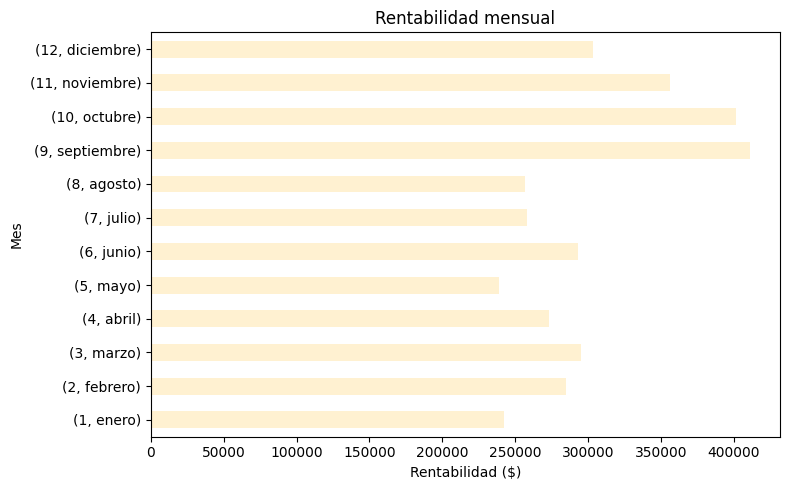

In [46]:
ganancia_mensual.plot(kind="barh", figsize=(8, 5), color="#FFF1D1")
plt.title("Rentabilidad mensual")
plt.xlabel("Rentabilidad ($)")
plt.ylabel("Mes")
plt.tight_layout()
plt.show()

In [47]:
print(f"La ganancia máxima fue de {ganancia_mensual.max()}")
print(f"la ganancia mínima fue de {ganancia_mensual.min()}")
print(f"el promedio de la ganancia mensual fue de {ganancia_mensual.mean().round(2)}")
print(f"entre el mes de menor y el de mayor rentabilidad, la ganancia mensual varió un {((ganancia_mensual.max() - ganancia_mensual.min()) / ganancia_mensual.min()) * 100:.2f}%.")

La ganancia máxima fue de 411230.0
la ganancia mínima fue de 239040.0
el promedio de la ganancia mensual fue de 301311.67
entre el mes de menor y el de mayor rentabilidad, la ganancia mensual varió un 72.03%.


**Conclusión** : La rentabilidad mensual mostró una tendencia general de crecimiento, aunque con diferentes variaciones mes a mes. La rentabilidad máxima fue en septiembre, con una ganancia de **$411.230**, mientras que la rentabilidad mínima es de **239.040** durante el mes de mayo. Por lo tanto, se podría decir que la variación durante el año fue de un **72,03%**.
Observando el gráfico, se ve una aceleración de la rentabilidad hacia septiembre y octubre, que concentran las barras más altas, mientras que los primeros meses del año muestran los valores más bajos. Esto sugiere que el negocio no creció de forma lineal, sino que tuvo un salto de rentabilidad marcado a partir de mediados de año.




**Pregunta 2:** ¿la propina esta mas influenciada por la satisfaccion del cliente (calificación) o por el monto consumido?

Para realizar el análisis, primero se sumaron las propinas y el consumo total por transacción, mientras que las calificaciones se promediaron. Luego se realizó un heatmap con el fin de analizar la correlación entre las 3 variables y un gráfico de dispersión para visualizar la relación entre ellas.

In [48]:
influencia_propina = data_set_limpio.groupby("id_transaccion").agg(propina_total=("propina", "sum"),calificacion=("calificacion", "mean"), consumo_total=("total_consumido", "sum"))
print(f" el promedio de la calificación es {influencia_propina["calificacion"].mean()}")
print(f" la moda de la calificación es {influencia_propina["calificacion"].mode()[0]}")
influencia_propina

 el promedio de la calificación es 4.252525252525253
 la moda de la calificación es 5.0


,propina_total,calificacion,consumo_total
id_transaccion,,,
T1001,2120.0,3.0,7090.0
T1002,1540.0,<NA>,7690.0
T1003,0.0,<NA>,4040.0
T1004,6030.0,<NA>,13370.0
T1005,0.0,4.0,16380.0
...,...,...,...
T1616,560.0,4.0,3740.0
T1617,4050.0,<NA>,13470.0
T1618,560.0,5.0,5600.0


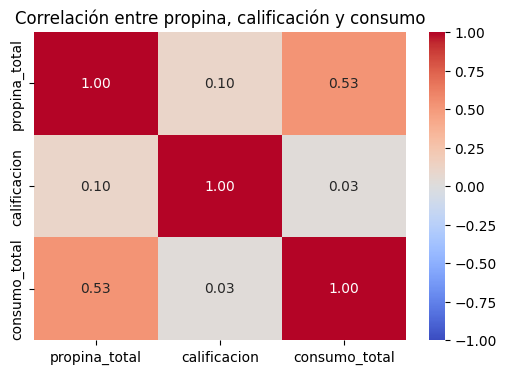

In [49]:
import seaborn as sns
plt.figure(figsize=(6,4))
influencia_propina2 = influencia_propina[["propina_total", "calificacion", "consumo_total"]].corr()
sns.heatmap(influencia_propina2, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlación entre propina, calificación y consumo")
plt.show()

Text(0, 0.5, 'Consumo Total ($)')

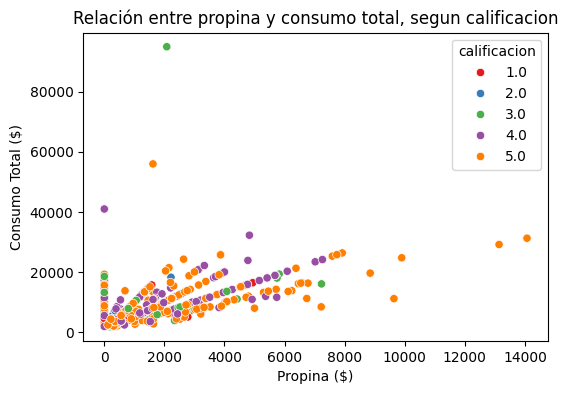

In [50]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=influencia_propina, x="propina_total", y="consumo_total", hue="calificacion", palette="Set1")
plt.title("Relación entre propina y consumo total, segun calificacion")
plt.xlabel("Propina ($)")
plt.ylabel("Consumo Total ($)")

**Conclusión**: La relación entre propina y calificación es débil, mientras que la relación entre propina y consumo total es mayormente directa, positiva con un valor de 0,53 sobre 1 (valor obtenido en el heatmap y visualizado en el scatterplot). Por lo tanto, podemos decir que el valor del consumo total tiene mucha influencia por sobre la propina, a diferencia de la calificación. En el gráfico de dispersión se visualiza la relación mayormente directa entre propina y consumo, además de como estas se ven afectadas por la calificación de los consumidores (análisis multivariado), que en promedio es 4,25 y la moda es 5

**Pregunta 3:** ¿Los precios aumentaron al mismo ritmo que los costos?

La pregunta hace referencia al aumento (subida) de los precios, es decir, no hace referencia a la variación, por lo que el promedio se puede calcular con valores negativos que indican incluso que los precios/costos disminuyeron. Para realizar el análisis en primero se calculó el promedio de los precios unitarios mensuales y el porcentaje de la variación. Finalmente se hizo un promedio del porcentaje de la variación anual para visualizarse en un gráfico de barras y ser comparado, tras realizar el mismo procedimiento, con el promedio de la variación anual de los costos.

In [51]:
precio_unitario_mensual = data_set_limpio.groupby("mes_num")["precio_unitario"].mean()
#a pesar de que en marzo y mayo los precios tuvieron una disminución, la tendencia siempre es hacia el aumento

variacion_porcentaje_precio = precio_unitario_mensual.pct_change()*100
variacion_porcentaje_precio

tabla_precios = pd.DataFrame({
    "precio_unitario_mensual": precio_unitario_mensual,
    "variacion_porcentaje_precio": variacion_porcentaje_precio
})
tabla_precios

,precio_unitario_mensual,variacion_porcentaje_precio
mes_num,,
1,3725.000000,NaN
2,4131.666667,10.917226
3,3952.142857,-4.345070
4,4032.083333,2.022712
5,3710.724638,-7.970041
6,4030.400000,8.614904
7,4035.285714,0.121222
8,3941.060606,-2.335029
9,3858.764045,-2.088183


In [52]:
print(f"el promedio de la variación positiva (aumento) durante el año fue de {variacion_porcentaje_precio.mean():.2f}%")

el promedio de la variación positiva (aumento) durante el año fue de 1.22%


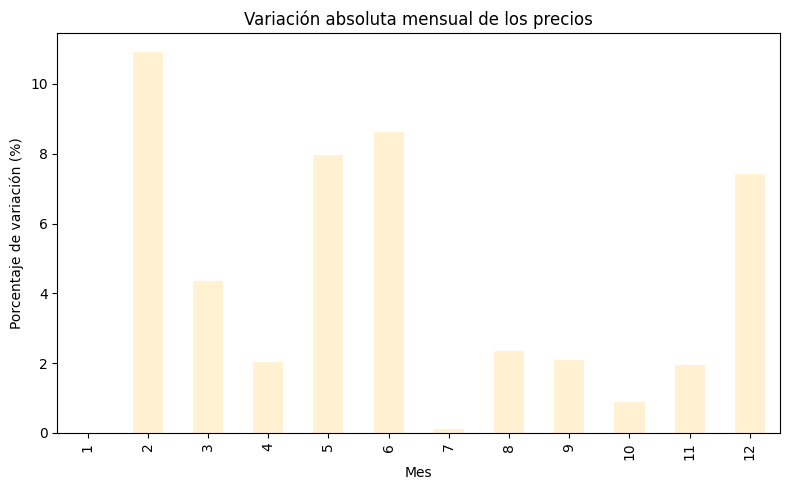

In [53]:
(tabla_precios["variacion_porcentaje_precio"].abs()).plot(kind="bar", figsize=(8, 5), color="#FFF1D1")
plt.title("Variación absoluta mensual de los precios")
plt.xlabel("Mes")
plt.ylabel("Porcentaje de variación (%)")
plt.tight_layout()
plt.show()
#gráfico de la variación (absoluta) de los precios a lo largo del año

In [54]:
costo_unitario_mensual = data_set_limpio.groupby("mes_num")["costo_unitario"].mean()

variacion_porcentaje_costo = costo_unitario_mensual.pct_change()*100
variacion_porcentaje_costo

tabla_costos = pd.DataFrame({
    "costo_unitario_mensual": costo_unitario_mensual,
    "variacion_porcentaje_costo": variacion_porcentaje_costo #que sean siempre valores positivos
})
tabla_costos

,costo_unitario_mensual,variacion_porcentaje_costo
mes_num,,
1,1099.861111,NaN
2,1257.878788,14.367057
3,1224.285714,-2.670613
4,1176.388889,-3.912226
5,1010.724638,-14.082439
6,1197.866667,18.515629
7,1194.285714,-0.298944
8,1058.484848,-11.370886
9,1110.561798,4.919952


In [55]:
print(f"el promedio de la variación positiva (aumento) durante el año fue de {variacion_porcentaje_costo.mean():.2f}%")

el promedio de la variación positiva (aumento) durante el año fue de 2.13%


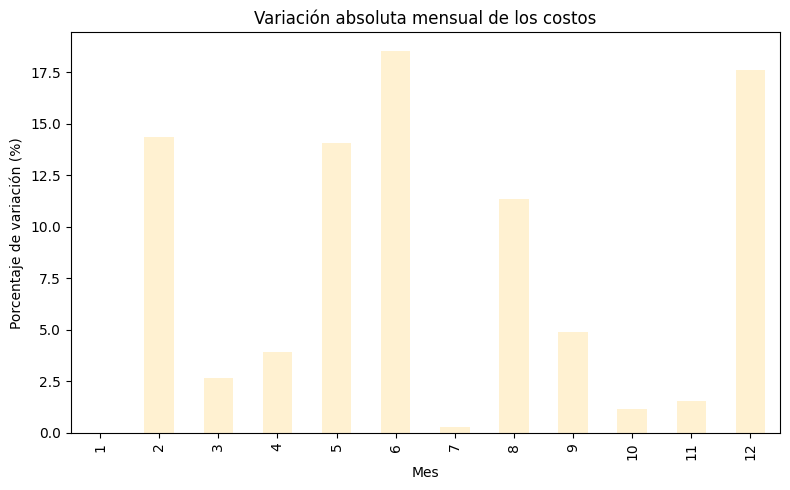

In [56]:
(tabla_costos["variacion_porcentaje_costo"].abs()).plot(kind="bar", figsize=(8, 5), color="#FFF1D1")
plt.title("Variación absoluta mensual de los costos")
plt.xlabel("Mes")
plt.ylabel("Porcentaje de variación (%)")
plt.tight_layout()
plt.show()
#gráfico de la variación (absoluta) de los costos a lo largo del año

**Conclusión**: A lo largo del año, los precios registraron una variación promedio del 1,22%, mientras que los costos aumentaron a un ritmo más del doble: 2,13%. Esta brecha indica que el negocio no trasladó completamente el incremento de costos a los precios de venta, lo cual es consistente con un contexto inflacionario donde los costos suelen ajustarse con mayor frecuencia o velocidad que los precios finales al público.

---
## 6.2 Síntesis de hallazgos

**Síntesis:** La rentabilidad mensual creció de forma no lineal, aumentando desde septiembre (máximo de 411.230 pesos mientras que el mínimo era de 239.040 en mayo, representando un aumento del 72% aproximadamente). La propina se relaciona más con el consumo total (correlación 0,53) que con la calificación del cliente (0,10). Los costos aumentaron a un ritmo mayor que los precios (2,13% vs 1,22%), evidenciando que el negocio no trasladó completamente la inflación de costos a sus precios de venta.


In [57]:
# Verificador de longitud (pegá tu texto entre las triples comillas)
sintesis = "La rentabilidad mensual creció de forma no lineal, aumentando desde septiembre (máximo $411.230 vs mínimo $239.040 en mayo, representando un aumento del 72% aproximadamente). La propina se relaciona más por el consumo total (correlación 0,53) que con la calificación del cliente (0,10). Los costos aumentaron a un ritmo mayor que los precios (2,13% vs 1,22%), evidenciando que el negocio no trasladó completamente la inflación de costos a sus precios de venta"
print(f"Caracteres: {len(sintesis)} / 500")
assert len(sintesis) <= 500, "⚠️ La síntesis supera los 500 caracteres: recortala."
print("✅ Longitud OK")

Caracteres: 459 / 500
✅ Longitud OK


In [58]:
data_set_limpio.to_csv('data_set_limpio.csv', index=False)

from google.colab import files
files.download('data_set_limpio.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>